# NFL Draft Prediction
**GCI World 2026 — OmniCampus Competition**  
Competition Period: April 29, 2026 – June 12, 2026  

**Goal:** Predict whether a college athlete will be selected in the NFL Draft (binary classification).  
**Evaluation Metric:** ROC-AUC  
**Final Score:** 0.84332 AUC (Top 20%)

---

### Approach Summary
1. Exploratory data analysis — class balance, missing values, correlations  
2. Feature engineering — speed score, explosive score, weight/height categories, target encoding, missing-value flags  
3. Smart missing value imputation — group-based medians by position/weight category  
4. Model selection via RandomizedSearchCV — GBM, RF, XGBoost, LightGBM  
5. Final model — XGBoost with Stratified K-Fold (5 folds), predictions averaged across folds

## 1. Imports

In [574]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

## 2. Load Data

In [575]:
train = pd.read_csv('train.csv', index_col='Id')
test  = pd.read_csv('test.csv',  index_col='Id')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (2781, 15)
Test shape:  (696, 14)


## 3. Exploratory Data Analysis

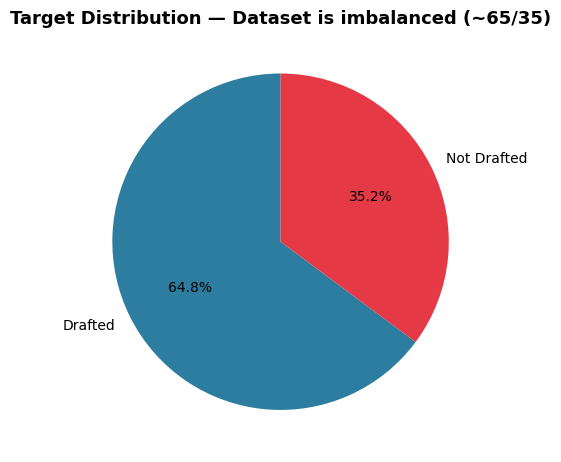

In [576]:
# --- Class balance ---
fig, ax = plt.subplots(figsize=(5, 5))
train['Drafted'].value_counts(normalize=True).plot(
    kind='pie',
    colors=['#2C7DA0', '#E63946'],
    labels=['Drafted', 'Not Drafted'],
    autopct='%1.1f%%',
    startangle=90,
    ax=ax
)
ax.set_title('Target Distribution — Dataset is imbalanced (~65/35)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [577]:
# --- Missing values ---
missing = train.isna().sum().sort_values(ascending=False)
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
Agility_3cone       970
Shuttle             912
Bench_Press_Reps    721
Broad_Jump          581
Vertical_Jump       554
Age                 435
Sprint_40yd         145
dtype: int64


Numeric feature correlations with Drafted:


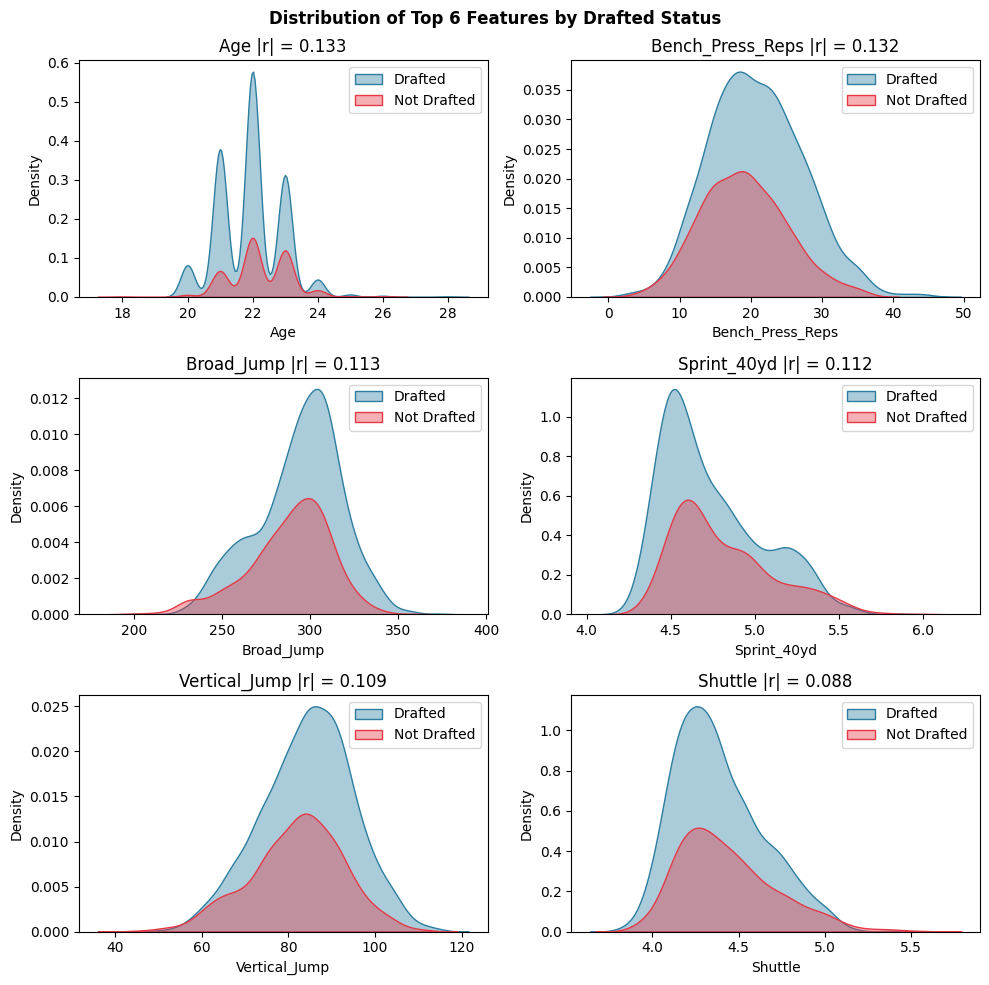

In [578]:
# --- Correlation with target ---
corr = train.corr(numeric_only=True)['Drafted'].abs().sort_values(ascending=False)[1:]
index = corr.index
value = corr.values
print("Numeric feature correlations with Drafted:")
fig,ax = plt.subplots(3,2,figsize=(10,10))
ax = ax.flatten()
for i in range(6):
    sns.kdeplot(data=train,x=index[i],hue='Drafted',ax=ax[i],fill=True,palette={1: '#2C7DA0', 0: '#E63946'},alpha=0.4)
    ax[i].set_title(f'{index[i]} |r| = {value[i]:.3f}')
    ax[i].legend(['Drafted','Not Drafted'])
plt.suptitle('Distribution of Top 6 Features by Drafted Status',fontweight='bold')
plt.tight_layout()

## 4. Feature Engineering

### 4.1 School prestige flag

In [579]:
# Flag players coming from top-40 schools by volume of prospects
top_schools = train.groupby('School').size().sort_values(ascending=False).head(40).index
train['is_top_school'] = train['School'].isin(top_schools).astype(int)
test['is_top_school']  = test['School'].isin(top_schools).astype(int)

### 4.2 Missing-value flags for combine metrics
Whether a player skipped a test can itself be informative.

In [580]:
combine_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle', 'Age']

for col in combine_cols:
    train[f'{col}_missing'] = train[col].isna().astype(np.int8)
    test[f'{col}_missing']  = test[col].isna().astype(np.int8)

# Total tests completed
train['combine_tests_completed'] = train[combine_cols].notna().sum(axis=1)
test['combine_tests_completed']  = test[combine_cols].notna().sum(axis=1)

### 4.3 Imputation
- Age/Year: training mean  
- Bench Press: position-group median (strength varies heavily by position)  
- Speed drills: weight-category mean (heavier athletes are inherently slower)  
- Jump metrics: speed-category mean (explosive athletes cluster together)

In [581]:
for col in ['Age', 'Year']:
    mean_val = train[col].mean()
    train[col] = train[col].fillna(mean_val)
    test[col]  = test[col].fillna(mean_val)

### 4.4 Body composition categories

In [582]:
# Height decile buckets (derived from training distribution)
_, bins = pd.qcut(train['Height'], 10, retbins=True, labels=False, duplicates='drop')
train['Height_cat'] = pd.cut(train['Height'], bins=bins, include_lowest=True, labels=range(1, 10))
test['Height_cat']  = pd.cut(test['Height'],  bins=bins, include_lowest=True, labels=range(1, 10))

# Weight — fixed bins for stability across train/test
weight_bins = np.array([67.5851, 87.09, 90.72, 94.80, 98.88,
                        104.78, 110.68, 117.48, 135.17, 141.07, 168.1])
train['Weight_cat'] = pd.cut(train['Weight'], bins=weight_bins, include_lowest=True, labels=range(1, 11))
test['Weight_cat']  = pd.cut(test['Weight'],  bins=weight_bins, include_lowest=True, labels=range(1, 11))

In [583]:
# Bench Press — impute by position median, then categorize
for col in ['Bench_Press_Reps']:
    group_median = train.groupby('Position_Type')[col].median().rename('fill_val')
    train = train.merge(group_median, on='Position_Type')
    test  = test.merge(group_median, on='Position_Type')
    train[col] = train[col].fillna(train['fill_val'])
    test[col]  = test[col].fillna(test['fill_val'])
    train.drop('fill_val', axis=1, inplace=True)
    test.drop('fill_val',  axis=1, inplace=True)

bins = np.array([ 2., 13., 15., 17., 18.,19.74842767, 21.4079602 ,23. , 25., 28.,49.])
train['power_cat'] = pd.cut(train['Bench_Press_Reps'], bins=bins, include_lowest=True, labels=range(1, 11))
test['power_cat']  = pd.cut(test['Bench_Press_Reps'],  bins=bins, include_lowest=True, labels=range(1, 11))

### 4.5 Speed score & category
Composite of the three timed drills, normalized to training maximums to avoid data leakage.

In [584]:
# Impute speed drills by weight category before building the score
for col in ['Shuttle', 'Agility_3cone', 'Sprint_40yd']:
    group_mean = train.groupby('Weight_cat')[col].mean().rename('fill_val')
    train = train.merge(group_mean, on='Weight_cat')
    test  = test.merge(group_mean, on='Weight_cat')
    train[col] = train[col].fillna(train['fill_val'])
    test[col]  = test[col].fillna(test['fill_val'])
    train.drop('fill_val', axis=1, inplace=True)
    test.drop('fill_val',  axis=1, inplace=True)

# Lower drill times = faster, so invert before normalizing
train_shuttle_max = (1 / train['Shuttle']).max()
train_sprint_max  = (1 / train['Sprint_40yd']).max()
train_agility_max = (1 / train['Agility_3cone']).max()

for df in [train, test]:
    df['speed_score'] = (
        (1 / df['Shuttle'])       / train_shuttle_max +
        (1 / df['Sprint_40yd'])  / train_sprint_max  +
        (1 / df['Agility_3cone']) / train_agility_max
    ) / 3

_, bins = pd.qcut(train['speed_score'], 8, retbins=True, labels=False)
train['speed_cat'] = pd.cut(train['speed_score'], bins=bins, include_lowest=True, labels=range(1, 9))
test['speed_cat']  = pd.cut(test['speed_score'],  bins=bins, include_lowest=True, labels=range(1, 9))

In [585]:
# Impute jump metrics by speed category
for col in ['Vertical_Jump', 'Broad_Jump']:
    group_mean = train.groupby('speed_cat')[col].mean().rename('fill_val')
    train = train.merge(group_mean, on='speed_cat')
    test  = test.merge(group_mean, on='speed_cat')
    train[col] = train[col].fillna(train['fill_val'])
    test[col]  = test[col].fillna(test['fill_val'])
    train.drop('fill_val', axis=1, inplace=True)
    test.drop('fill_val',  axis=1, inplace=True)

### 4.6 Composite athletic features

In [586]:
train_vj_max = train['Vertical_Jump'].max()
train_bj_max = train['Broad_Jump'].max()

for df in [train, test]:
    df['weight_speed']      = df['Weight'] * df['speed_score'] ** 3
    df['power_speed_ratio'] = df['Bench_Press_Reps'] * df['speed_score'] ** 2
    df['height_speed']      = df['Height'] * df['speed_score']
    df['power_to_weight']   = df['Bench_Press_Reps'] / df['Weight']
    df['explosion']         = (df['Vertical_Jump'] / train_vj_max + df['Broad_Jump'] / train_bj_max) / 2
    df['BMI']               = df['Weight'] / (df['Height'] ** 2)

_, bins = pd.qcut(train['explosion'], 8, retbins=True, labels=False, duplicates='drop')
train['explosion_cat'] = pd.cut(train['explosion'], bins=bins, include_lowest=True, labels=range(1, 9))
test['explosion_cat']  = pd.cut(test['explosion'],  bins=bins, include_lowest=True, labels=range(1, 9))

### 4.7 Group-level target encoding features

In [587]:
group_features = [
    (['speed_cat', 'Weight_cat'], 'mean',   'speed_weight'),
    (['Year', 'Position_Type'],  'median',  'year_position_type'),
    (['Weight_cat', 'Player_Type'], 'mean', 'weight_player_type'),
    (['Age', 'speed_cat'],       'mean',    'age_speed'),
    (['Age', 'Player_Type'],     'mean',    'age_type'),
    (['Age', 'Year'],            'mean',    'age_year'),
]

for keys, agg, feat_name in group_features:
    stats = train.groupby(keys)['Drafted'].agg(agg)
    train[feat_name] = train.set_index(keys).index.map(stats)
    test[feat_name]  = test.set_index(keys).index.map(stats)

# Speed rank within year and position group
train['year_speed_rank'] = train.groupby(['Year', 'Position_Type'])['Sprint_40yd'].rank(pct=True)
test['year_speed_rank']  = test.groupby(['Year', 'Position_Type'])['Sprint_40yd'].rank(pct=True)

### 4.8 Overall athlete score & smoothed target encoding

In [588]:
cat_cols = ['power_cat', 'Weight_cat', 'Height_cat', 'speed_cat', 'explosion_cat']
for df in [train, test]:
    for col in cat_cols:
        df[col] = df[col].astype(int)

# Speed weighted double — most predictive of draft outcome
train['overall_score'] = (train['power_cat'] + train['Weight_cat'] +
                          train['Height_cat'] + 2 * train['speed_cat'] + train['explosion_cat'])
test['overall_score']  = (test['power_cat']  + test['Weight_cat']  +
                          test['Height_cat']  + 2 * test['speed_cat']  + test['explosion_cat'])

# Smoothed target encoding for position (avoids overfitting rare positions)
alpha = 10
global_mean = train['Drafted'].mean()

for col in ['Position_Type', 'Position']:
    stats = train.groupby(col)['Drafted'].agg(['mean', 'count'])
    stats['smoothed'] = (
        (stats['mean'] * stats['count'] + global_mean * alpha) /
        (stats['count'] + alpha)
    )
    train[f'{col}_te'] = train[col].map(stats['smoothed'])
    test[f'{col}_te']  = test[col].map(stats['smoothed']).fillna(global_mean)

## 5. Prepare Final Feature Sets

In [589]:
drop_cols = ['School', 'Weight', 'Position', 'Year', 'Weight_cat',
             'power_cat', 'Height_cat', 'Age', 'Position_Type',
             'speed_cat', 'explosion_cat', 'Player_Type']

train_clean = train.drop(columns=drop_cols).dropna()
test.drop(columns=drop_cols, inplace=True)
test = test.fillna(test.mean(numeric_only=True))

X    = train_clean.drop('Drafted', axis=1)
Y    = train_clean['Drafted']
x_ts = test
y_ts = None # The labels of the testset are not given by omnicampus

print(f"Training features: {X.shape}")
print(f"Test features:     {x_ts.shape}")

Training features: (2781, 33)
Test features:     (696, 33)


## 6. Model Selection via RandomizedSearchCV

In [590]:
xgb_params = {
    'n_estimators':  [500, 700, 900, 1400],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'max_depth':     [1, 3, 4],
    'subsample':     [0.3, 0.5, 0.7, 0.9],
}
rf_params = {
    'n_estimators':      [50, 100, 400, 800, 1200],
    'max_features':      [5, 10, 15, 20],
    'max_depth':         [1, 3, 6, None],
    'min_samples_split': [2, 6, 12],
}
gb_params = {
    'n_estimators':      [50, 100, 400, 800, 1200],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [1, 3, 6, 10, None],
    'min_samples_split': [2, 6, 10],
    'subsample':         [0.3, 0.5, 0.7, 0.9],
}

models = {
    'GradientBoosting': (GradientBoostingClassifier(), gb_params),
    'RandomForest':     (RandomForestClassifier(),     rf_params),
    'XGBoost':          (XGBClassifier(),              xgb_params)
}

print("Running RandomizedSearchCV (3-fold, 20 iterations each)...")
results = {}
for name, (model, params) in models.items():
    search = RandomizedSearchCV(model, params, cv=3, scoring='roc_auc',
                                n_iter=20, n_jobs=-1, random_state=42)
    search.fit(X, Y)
    results[name] = search.best_score_
    print(f"  {name:20s}  best AUC = {search.best_score_:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nBest model: {best_model_name} (AUC = {results[best_model_name]:.4f})")

Running RandomizedSearchCV (3-fold, 20 iterations each)...
  GradientBoosting      best AUC = 0.8456
  RandomForest          best AUC = 0.8469
  XGBoost               best AUC = 0.8489

Best model: XGBoost (AUC = 0.8489)


## 7. Final Model — XGBoost with Stratified K-Fold

XGBoost achieved the best RandomizedSearchCV score (0.8489).  
Predictions are averaged across all 5 folds to reduce variance.

In [591]:
final_model = XGBClassifier(
    enable_categorical=True,
    subsample=0.5,
    n_estimators=500,
    max_depth=4,
    learning_rate=0.01,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
val_auc_scores       = []
test_pred_proba_list = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, Y), start=1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = Y.iloc[train_idx], Y.iloc[valid_idx]

    final_model.fit(X_train, y_train)

    val_proba = final_model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, val_proba)
    val_auc_scores.append(auc)
    print(f"  Fold {fold}  Validation AUC: {auc:.4f}")


print(f"\nMean Validation AUC: {np.mean(val_auc_scores):.4f}  ")

  Fold 1  Validation AUC: 0.8210
  Fold 2  Validation AUC: 0.8779
  Fold 3  Validation AUC: 0.8632
  Fold 4  Validation AUC: 0.8098
  Fold 5  Validation AUC: 0.8618

Mean Validation AUC: 0.8467  


## 8. Generate Submission

The final test predictions are submitted to the 
competition platform at **OmniCampus GCI World** to obtain the final ROC-AUC score.

The submission file is generated in the required format and uploaded for evaluation.

In [592]:
# Store predictions
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_pred_proba_list = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, Y)):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = Y.iloc[train_idx], Y.iloc[valid_idx]

    # Train the model on this fold
    model.fit(X_train, y_train)

    # Save predictions for the test set
    test_pred_proba = model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# Average test predictions across folds
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)